## Phase 1: Data Understanding and Cleaning

### Objectives

In this phase we will:

- Load and understand the structure of the House Prices dataset
- Identify and handle duplicate entries
- Analyze data types and categorize features
- Identify and handle missing values
- Detect and handle outliers
- Create a clean baseline dataset for further processing

### Notes

- We keep a raw copy (`df`) and create a cleaned working copy (`df_clean`).
- Any cleaning decisions (drop / impute / outlier handling) are documented in markdown cells near the relevant step.


In [1]:
# Task 1: Import Libraries
import os

os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".matplotlib"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Set display options for better readability
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")


Libraries imported successfully!


### Task 2: Load the Dataset

We load `train.csv` and inspect:

- **Rows / observations**
- **Columns / features**
- **Target variable** (the label we want to predict)


In [2]:
# Task 2: Load the Dataset
df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")
print("Dataset shape (rows, columns):", df.shape)
print("Number of observations (rows):", df.shape[0])
print("Number of features (columns):", df.shape[1])

target = "SalePrice"
print("Target variable:", target)

df.head()

Dataset loaded successfully!
Dataset shape (rows, columns): (1460, 81)
Number of observations (rows): 1460
Number of features (columns): 81
Target variable: SalePrice


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Dataset information (data types, non-null counts)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

### Your Observations (Task 2)

- **Total rows**: 1460
- **Total columns**: 81
- **Target variable**: `SalePrice`
- **Notable features**:
  - Mix of **numerical** (`int64`/`float64`) and **categorical** (`object`) features.
  - Several features have substantial missingness (e.g., `Alley`, `PoolQC`, `Fence`, `MiscFeature`, `FireplaceQu`, `LotFrontage`).
  - Some “NA” values are **missing by design** (meaning the house lacks that feature), per `data_description.txt` (e.g., no basement / no garage / no pool).


### Task 3: Check for Duplicate Rows

We check for **exact duplicate** observations. If any exist, we remove them because they do not add new information and can bias training.

In [4]:
# Task 3: Check for Duplicate Rows

duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].head(20))
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found. No rows removed.")

Duplicate rows found: 0
No duplicates found. No rows removed.


### Decision (Task 3)

- If **0 duplicates** are found, we keep the dataset unchanged.
- If duplicates exist, we **drop exact duplicates** (same values across all columns), because they represent repeated records rather than distinct properties.

### Task 4: Identify Feature Types

We split features into **categorical** and **numerical** based on dtype, then check cardinality of categorical variables.

Note: Some integer-coded fields (e.g., `MSSubClass`) are *conceptually categorical* even though they are stored as numbers.

In [ ]:
# Task 4: Identify Feature Types

cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols  = df.select_dtypes(include=["number"]).columns.tolist()

print(f"Categorical columns: {len(cat_cols)}")
print(f"Numerical columns: {len(num_cols)}")

print("\nCategorical columns:\n", cat_cols)
print("\nNumerical columns:\n", num_cols)

# Unique values in categorical columns (high cardinality first)
cat_cardinality = df[cat_cols].nunique().sort_values(ascending=False)
display(cat_cardinality.to_frame("unique_values"))

# Numerical columns that are conceptually categorical (integer codes / calendar categories)
numeric_as_categorical = [
    "MSSubClass",  # dwelling type codes
    "MoSold",      # month category
    "YrSold",      # year category
]

# Keep only those that exist
numeric_as_categorical = [c for c in numeric_as_categorical if c in df.columns]
print("\nNumeric columns to treat as categorical in preprocessing:", numeric_as_categorical)
/Users/worklaptop1/Desktop/Pythone/House Pricing/House Pricing 4/Data Cleaning.ipynb


Categorical columns: 43
Numerical columns: 38

Categorical columns:
 ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

Numerical columns:
 ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd

/var/folders/w4/64xd5rm541v4ws_zqv6kzcj00000gn/T/ipykernel_9029/3070664430.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


,unique_values
Neighborhood,25
Exterior2nd,16
Exterior1st,15
SaleType,9
Condition1,9
Condition2,8
HouseStyle,8
RoofMatl,8
Functional,7
BsmtFinType2,6



Numeric columns to treat as categorical in preprocessing: ['MSSubClass', 'MoSold', 'YrSold']


### Answer (Task 4)

Numerical columns that should be treated as categorical:

- **`MSSubClass`**: integer codes for dwelling type (not a continuous numeric measure).
- **`MoSold`**: month of sale (cyclical category; usually encoded categorically or with cyclical transforms).
- **`YrSold`**: year of sale (discrete time periods; often treated as categorical or ordinal depending on modeling choice).

Other numeric “ratings” like `OverallQual` and `OverallCond` are **ordinal** and can often remain numeric (or be treated as ordered categories later), depending on the modeling approach.

### Task 5: Analyze Missing Values

We quantify missingness per column (count + percentage) and visualize the most-missing features.

Features with missing values: 19


,Column,Missing_Count,Missing_Percentage
0,PoolQC,1453,99.52
1,MiscFeature,1406,96.30
2,Alley,1369,93.77
3,Fence,1179,80.75
4,MasVnrType,872,59.73
5,FireplaceQu,690,47.26
6,LotFrontage,259,17.74
7,GarageType,81,5.55
8,GarageYrBlt,81,5.55
9,GarageFinish,81,5.55


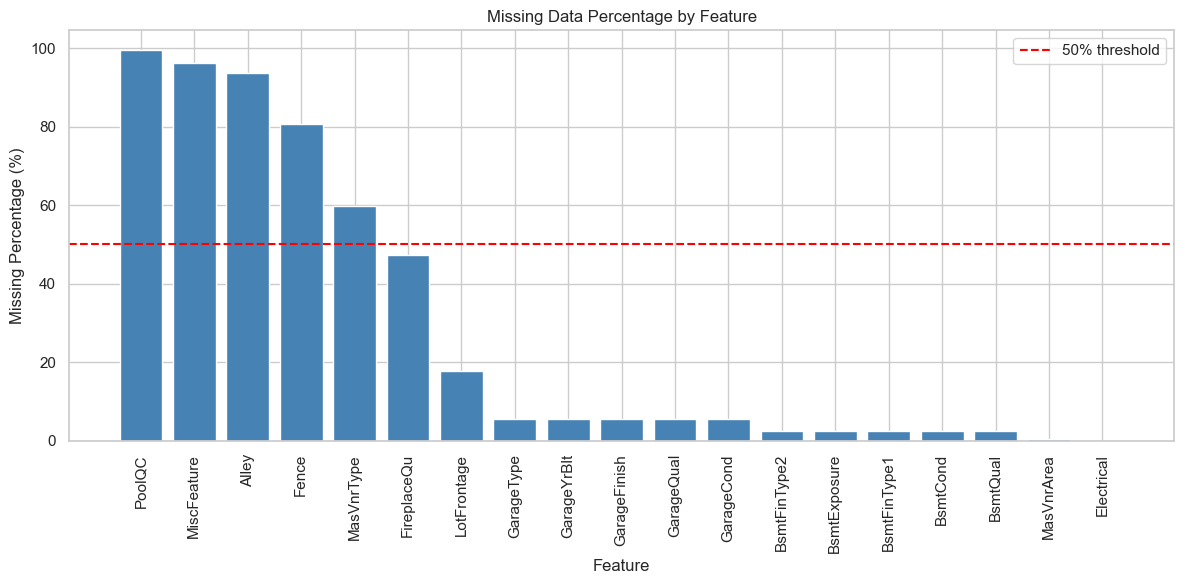

In [6]:
# Task 5: Analyze Missing Values

total_rows = df.shape[0]
missing_count = df.isnull().sum()
missing_pct = (missing_count / total_rows * 100).round(2)

missing_summary = (
    pd.DataFrame(
        {
            "Column": missing_count.index,
            "Missing_Count": missing_count.values,
            "Missing_Percentage": missing_pct.values,
        }
    )
    .query("Missing_Count > 0")
    .sort_values("Missing_Percentage", ascending=False)
    .reset_index(drop=True)
)

print(f"Features with missing values: {missing_summary.shape[0]}")
display(missing_summary)

# Bar plot of missing percentages
plt.figure(figsize=(12, 6))
plt.bar(missing_summary["Column"], missing_summary["Missing_Percentage"], color="steelblue")
plt.axhline(50, color="red", linestyle="--", linewidth=1.5, label="50% threshold")
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("Missing Percentage (%)")
plt.title("Missing Data Percentage by Feature")
plt.legend()
plt.tight_layout()
plt.show()

### Task 6: Handle Missing Values

#### Strategy

- **High missing rate**: consider dropping, especially when the feature is sparse and likely low-signal.
- **Missing by design**: if NA means the house *does not have* that feature (per `data_description.txt`), we impute with explicit categories like `"None"` (or `0` for areas/values).
- **Otherwise**: impute using **mode** for categorical features and **median** (robust) for numeric features.

We will create `df_clean` as a working copy and keep `df` as the raw dataset.

In [7]:
# Task 6: Handle Missing Values

df_clean = df.copy()

# Step 6.1: Features to drop (very sparse + likely low-signal)
# (We keep some >50% missing features if NA means "feature absent" and can still be informative.)
features_to_drop = ["PoolQC", "MiscFeature", "Alley", "Fence"]
features_to_drop = [c for c in features_to_drop if c in df_clean.columns]

if features_to_drop:
    df_clean = df_clean.drop(columns=features_to_drop)
    print(f"Dropped {len(features_to_drop)} features: {features_to_drop}")
else:
    print("No features dropped.")

# Step 6.2: Categorical imputations
# Missing by design → 'None'
none_fill_cols = [
    # Basement
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    # Fireplace
    "FireplaceQu",
    # Garage
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    # Masonry veneer
    "MasVnrType",
]
none_fill_cols = [c for c in none_fill_cols if c in df_clean.columns]

for c in none_fill_cols:
    df_clean[c] = df_clean[c].fillna("None")

# Remaining categorical missing values → mode
cat_cols_clean = [c for c in df_clean.columns if df_clean[c].dtype == "object"]
cat_missing = [c for c in cat_cols_clean if df_clean[c].isnull().any()]

for c in cat_missing:
    df_clean[c] = df_clean[c].fillna(df_clean[c].mode(dropna=True)[0])

print("Categorical columns still missing after imputation:", [c for c in cat_cols_clean if df_clean[c].isnull().any()])

# Step 6.3: Numerical imputations
# LotFrontage: use Neighborhood median (more realistic than global median)
if "LotFrontage" in df_clean.columns:
    df_clean["LotFrontage"] = df_clean.groupby("Neighborhood")["LotFrontage"].transform(
        lambda s: s.fillna(s.median())
    )
    df_clean["LotFrontage"] = df_clean["LotFrontage"].fillna(df_clean["LotFrontage"].median())

# MasVnrArea: missing usually means no veneer
if "MasVnrArea" in df_clean.columns:
    df_clean["MasVnrArea"] = df_clean["MasVnrArea"].fillna(0)

# GarageYrBlt: missing usually means no garage
if "GarageYrBlt" in df_clean.columns:
    df_clean["GarageYrBlt"] = df_clean["GarageYrBlt"].fillna(0)

# Electrical is categorical; sometimes has a single NA → handled above via mode

remaining_missing = int(df_clean.isnull().sum().sum())
print("Total remaining missing values:", remaining_missing)

if remaining_missing > 0:
    still_missing = df_clean.isnull().sum()
    still_missing = still_missing[still_missing > 0].sort_values(ascending=False)
    display(still_missing.to_frame("missing_count"))

Dropped 4 features: ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
Categorical columns still missing after imputation: []
Total remaining missing values: 1


,missing_count
Electrical,1


### Task 7: Detect and Analyze Outliers

We visualize outliers with boxplots for key size/area variables and the target, then compute outliers using the **IQR rule**.

Important: outliers are not automatically “bad” — some represent valid expensive/large homes.

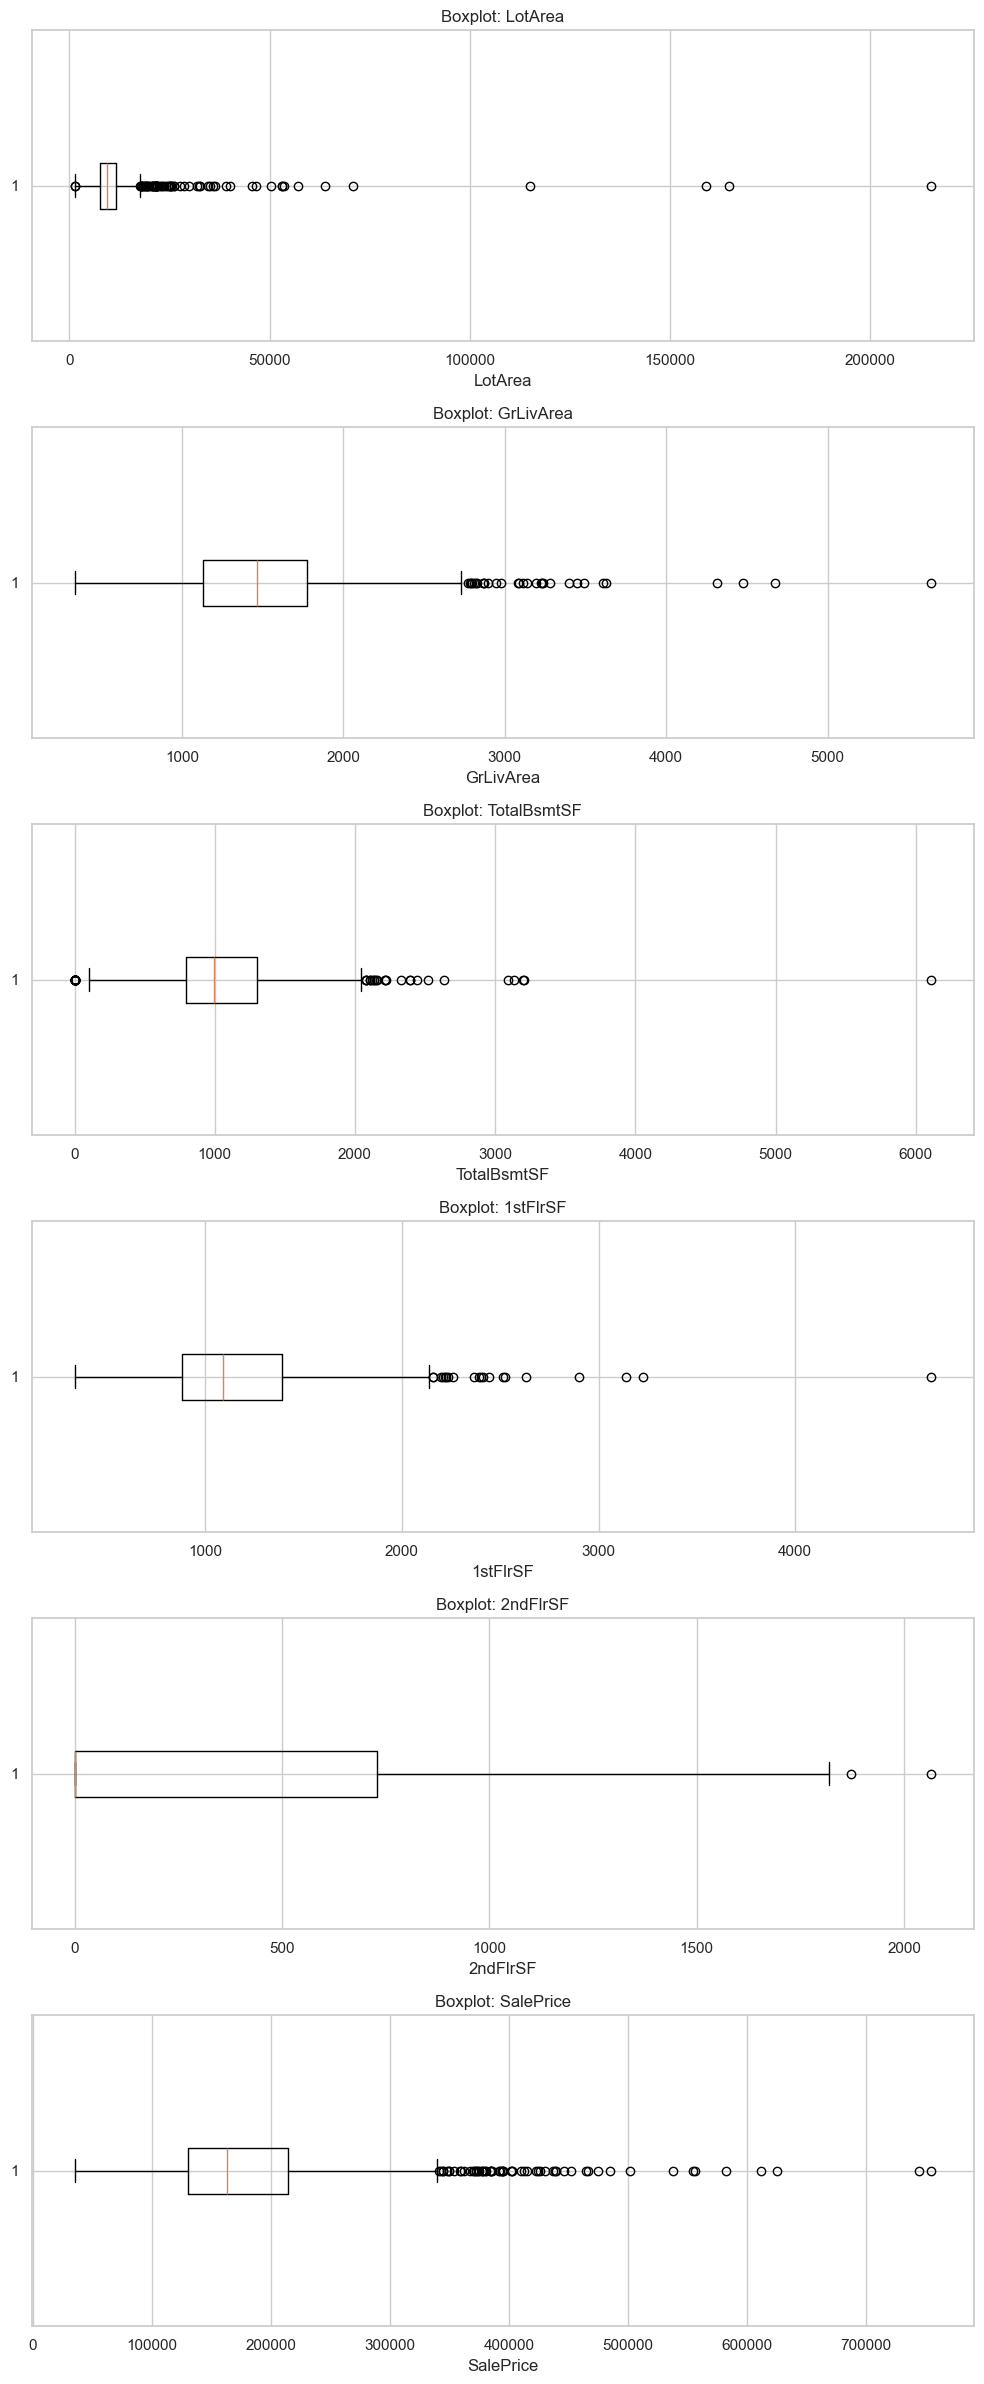

In [8]:
# Task 7: Outlier visualization (boxplots)

key_numeric_features = [
    "LotArea",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "SalePrice",
]

key_numeric_features = [c for c in key_numeric_features if c in df_clean.columns]

n = len(key_numeric_features)
fig, axes = plt.subplots(n, 1, figsize=(10, 4 * n))

if n == 1:
    axes = [axes]

for i, col in enumerate(key_numeric_features):
    axes[i].boxplot(df_clean[col].dropna(), vert=False)
    axes[i].set_title(f"Boxplot: {col}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [9]:
# Step 7.1: IQR outlier detection

def iqr_outliers(series: pd.Series):
    x = series.dropna().values
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

for col in key_numeric_features:
    mask, lower, upper = iqr_outliers(df_clean[col])
    print(f"{col}: lower={lower:.2f}, upper={upper:.2f}, outliers={int(mask.sum())}")

LotArea: lower=1481.50, upper=17673.50, outliers=69
GrLivArea: lower=158.62, upper=2747.62, outliers=31
TotalBsmtSF: lower=42.00, upper=2052.00, outliers=61
1stFlrSF: lower=118.12, upper=2155.12, outliers=20
2ndFlrSF: lower=-1092.00, upper=1820.00, outliers=2
SalePrice: lower=3937.50, upper=340037.50, outliers=61


### Decision (Task 7)

For this Kaggle dataset, a common and defensible baseline is to remove a small number of extreme points that look inconsistent (very large living area but relatively low sale price), as they can distort linear models.

We will:

- Inspect the largest `GrLivArea` homes.
- Remove observations where **`GrLivArea` is extremely large** yet **`SalePrice` is unusually low**.

This keeps legitimate high-end homes (large *and* high price) while removing likely anomalies.

In [10]:
# Step 7.2: Inspect and (optionally) remove extreme outliers

if {"GrLivArea", "SalePrice"}.issubset(df_clean.columns):
    extreme_area = df_clean.sort_values("GrLivArea", ascending=False).head(10)
    display(extreme_area[["GrLivArea", "SalePrice", "OverallQual", "OverallCond"]])

    # Remove a small set of inconsistent extreme points
    before_rows = df_clean.shape[0]
    df_clean = df_clean[~((df_clean["GrLivArea"] > 4000) & (df_clean["SalePrice"] < 300000))].copy()
    after_rows = df_clean.shape[0]

    print(f"Rows removed as extreme outliers: {before_rows - after_rows}")
else:
    print("Required columns for outlier rule not found; skipping outlier removal.")

,GrLivArea,SalePrice,OverallQual,OverallCond
1298,5642,160000,10,5
523,4676,184750,10,5
1182,4476,745000,10,5
691,4316,755000,10,6
1169,3627,625000,10,5
185,3608,475000,10,9
304,3493,295000,7,9
1268,3447,381000,8,9
635,3395,200000,6,7
769,3279,538000,8,5


Rows removed as extreme outliers: 2


### Task 8: Final Data Verification

We confirm the cleaned dataset:

- Has the expected shape
- Has **0 remaining missing values**
- Is saved for the next phase as `train_cleaned.csv`

In [11]:
# Task 8: Final verification + export

original_shape = df.shape
clean_shape = df_clean.shape

print("Original shape:", original_shape)
print("Cleaned shape:", clean_shape)
print("Rows removed:", original_shape[0] - clean_shape[0])
print("Columns removed:", original_shape[1] - clean_shape[1])

remaining_missing = int(df_clean.isnull().sum().sum())
print("Remaining missing values:", remaining_missing)

print("\nDtype counts (cleaned):")
print(df_clean.dtypes.value_counts())

# Save
output_path = "train_cleaned.csv"
df_clean.to_csv(output_path, index=False)
print(f"Saved cleaned dataset to: {output_path}")

Original shape: (1460, 81)
Cleaned shape: (1458, 77)
Rows removed: 2
Columns removed: 4
Remaining missing values: 1

Dtype counts (cleaned):
str        39
int64      35
float64     3
Name: count, dtype: int64
Saved cleaned dataset to: train_cleaned.csv
